In [1]:
import mitsuba as mi

mi.set_variant("llvm_ad_mono_polarized")

import sionna.rt
from sionna.rt import *


In [2]:
def load_base_scene():

    scene = load_scene(sionna.rt.scene.box)  # 네가 기존에 쓰던 함수

    scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
    )

    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="iso",
        polarization="V"
    )

    tx = Transmitter(
        name="tx",
        position=[-4, -4, 1]
    )

    rx0 = Receiver(
        name="rx0",
        position=[4, 4, 1.0]
    )

    rx1 = Receiver(
        name="rx1",
        position=[-4, 4, 1.0]
    )

    rx2 = Receiver(
        name="rx2",
        position=[4, -4, 1.0]
    )

    scene.add(tx)
    scene.add(rx0)
    scene.add(rx1)
    scene.add(rx2)


    return scene



# 방해물 객체 생성하기

In [3]:
from sionna.rt import RadioMaterial

# 사람
human_mat = RadioMaterial(
    name="human_mat",
    relative_permittivity=38.0,
    conductivity=1.5
)

# 나무 (책장, 책상, 의자, 문)
wood_mat = RadioMaterial(
    name="wood_mat",
    relative_permittivity=2.5,
    conductivity=0.01
)

# 콘크리트 벽
concrete_mat = RadioMaterial(
    name="concrete_mat",
    relative_permittivity=5.3,
    conductivity=0.1
)

# 유리
glass_mat = RadioMaterial(
    name="glass_mat",
    relative_permittivity=6.5,
    conductivity=0.01
)

# 금속 (냉장고, TV 프레임, 반사판)
metal_mat = RadioMaterial(
    name="metal_mat",
    relative_permittivity=1e4,
    conductivity=1e6
)


### 방해물 생성  

In [4]:
OBJECT_LIBRARY = {

    "human": {
        "scale": (0.35, 0.25, 0.85),
        "material": human_mat
    },

    "bookshelf": {
        "scale": (0.40, 0.15, 1.00),
        "material": wood_mat
    },

    "wardrobe": {
        "scale": (0.60, 0.30, 1.00),
        "material": wood_mat
    },

    "table": {
        "scale": (0.60, 0.40, 0.375),
        "material": wood_mat
    },

    "chair": {
        "scale": (0.25, 0.25, 0.45),
        "material": wood_mat
    },

    "door": {
        "scale": (0.45, 0.025, 1.00),
        "material": wood_mat
    },

    "refrigerator": {
        "scale": (0.40, 0.40, 0.90),
        "material": metal_mat
    },

    "tv": {
        "scale": (0.60, 0.025, 0.40),
        "material": metal_mat
    },

    "metal_panel": {
        "scale": (0.50, 0.025, 0.75),
        "material": metal_mat
    }
}

In [5]:
import mitsuba as mi
import drjit as dr

from sionna.rt import SceneObject

def create_object(
    obj_type,
    x,
    y,
    z,
    obj_id=0
):

    cfg = OBJECT_LIBRARY[obj_type]

    # 기본 Cube 생성
    mesh = mi.load_dict({
        "type": "cube"
    })

    sx, sy, sz = cfg["scale"]

    vertices = dr.unravel(
        mi.Point3f,
        mesh.vertex_positions_buffer()
    )

    # 크기 조절
    vertices = mi.Point3f(
        vertices.x * sx,
        vertices.y * sy,
        vertices.z * sz
    )

    # 위치 이동
    vertices += mi.Vector3f(
        x,
        y,
        z
    )

    params = mi.traverse(mesh)

    params["vertex_positions"] = dr.ravel(vertices)

    params.update()

    return SceneObject(
        mi_mesh=mesh,
        name=f"{obj_type}_{obj_id}",
        radio_material=cfg["material"]
    )

In [6]:
    

import random


def random_object(i):

    obj_type = random.choice(
        list(OBJECT_LIBRARY.keys())
    )

    return create_object(
        obj_type=obj_type,
        x=random.uniform(-2,2),
        y=random.uniform(-2,2),
        z=1.0,
        obj_id=i
    )

### 씬 빌드하기 

In [7]:
def build_scene(
    base_scene,
    objects
):

    add_objects = []

    for i, obj_info in enumerate(objects):

        obj_type = obj_info["type"]

        x, y, z = obj_info["pos"]

        scene_obj = create_object(
            obj_type=obj_type,
            x=x,
            y=y,
            z=z,
            obj_id=i
        )

        add_objects.append(
            scene_obj
        )

    sim_scene = rt.scene.edit_scene_shapes(
        base_scene,
        add=add_objects
    )

    return base_scene, sim_scene



### shape 확인 

In [8]:
def print_shapes(scene):

    print("===== SHAPES =====")

    for s in scene.mi_scene.shapes():
        print(s.id())

In [29]:
from sionna.rt import PathSolver
import numpy as np

solver = PathSolver()

def compute_mean_amp(scene):

    paths = solver(
        scene=scene,
        max_depth=3
    )

    a, tau = paths.cir()

    amp = np.mean(
        np.abs(np.array(a))
    )

    return amp, paths

# 휴먼 테스트 로직 

* Wifi 송수신기 설정하기 ( 한번만 실행하기 )

In [10]:
BASE_SCENE = load_base_scene()

In [11]:
import random

NUM_ENVS = 1000

environments = []

for env_id in range(NUM_ENVS):

    n_objects = random.randint(1, 5)

    env = []

    for obj_id in range(n_objects):

        env.append(
            {
                "type": random.choice(
                    list(OBJECT_LIBRARY.keys())
                ),

                "pos": (
                    random.uniform(-2.0, 2.0),
                    random.uniform(-2.0, 2.0),
                    random.uniform(0.5, 1.5)
                )
            }
        )

    environments.append(env)

print("num_envs =", len(environments))
print(environments[0])

num_envs = 1000
[{'type': 'table', 'pos': (-0.21545384061230832, 1.9706977091316187, 1.2628128830427752)}]


In [ ]:
# paths = solver(
#     scene=scene,
#     max_depth=5
# )

# a, tau = paths.cir()

# a_np = np.array(a)
# tau_np = np.array(tau)

# # 3. 데이터 형태(Shape) 확인 
# # 보통 [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths] 형태를 가짐
# print("Amplitude shape:", a_np.shape)
# print("Delay shape:", tau_np.shape)

Amplitude shape: (2, 3, 1, 1, 1, 192, 1)
Delay shape: (3, 1, 192)


In [28]:
base_scene, base_sim_scene = build_scene(
    BASE_SCENE,
    []
)

with base_scene.use_mi_scene(base_sim_scene):

    base_amp, _ = compute_mean_amp(base_scene)

print("Base amp:", base_amp)

Base amp: 0.00017521871


In [30]:
results = []

for env_id, env in enumerate(environments):

    scene, sim_scene = build_scene(
        BASE_SCENE,
        env
    )

    with scene.use_mi_scene(sim_scene):

        mean_amp, paths = compute_mean_amp(scene)

        a, tau = paths.cir()

    a_np = np.array(a)
    tau_np = np.array(tau)

    csi_amp = np.abs(a_np)
    csi_phase = np.angle(a_np)

    result = {
        "env_id": env_id,

        # 환경 정보
        "num_objects": len(env),
        "objects": env,

        # 채널 정보
        "mean_amp": float(mean_amp),
        "factor": float(mean_amp / base_amp),

        "CSIamp": csi_amp.astype(np.float32),
        "CSIphase": csi_phase.astype(np.float32),

        "tau": tau_np.astype(np.float32)
    }

    results.append(result)

    if env_id % 10 == 0:
        print(
            f"[{env_id:04d}] "
            f"amp={mean_amp:.8f} "
            f"factor={mean_amp/base_amp:.3f} "
            f"objs={len(env)}"
        )

[0000] amp=0.00024607 factor=1.404 objs=1
[0010] amp=0.00027490 factor=1.569 objs=4
[0020] amp=0.00024988 factor=1.426 objs=1
[0030] amp=0.00020748 factor=1.184 objs=4
[0040] amp=0.00027256 factor=1.556 objs=5
[0050] amp=0.00025249 factor=1.441 objs=5
[0060] amp=0.00026697 factor=1.524 objs=2
[0070] amp=0.00021565 factor=1.231 objs=5
[0080] amp=0.00024656 factor=1.407 objs=1
[0090] amp=0.00025810 factor=1.473 objs=5
[0100] amp=0.00024397 factor=1.392 objs=5
[0110] amp=0.00022980 factor=1.312 objs=5
[0120] amp=0.00027877 factor=1.591 objs=2
[0130] amp=0.00024399 factor=1.392 objs=3
[0140] amp=0.00027269 factor=1.556 objs=3
[0150] amp=0.00024204 factor=1.381 objs=4
[0160] amp=0.00026536 factor=1.514 objs=3
[0170] amp=0.00025761 factor=1.470 objs=3
[0180] amp=0.00024198 factor=1.381 objs=1
[0190] amp=0.00025082 factor=1.431 objs=3
[0200] amp=0.00024442 factor=1.395 objs=1
[0210] amp=0.00025676 factor=1.465 objs=4
[0220] amp=0.00023673 factor=1.351 objs=1
[0230] amp=0.00024306 factor=1.387

In [31]:
print(results[0]["CSIamp"].shape)
print(results[0]["CSIphase"].shape)
print(results[0]["tau"].shape)

(2, 3, 1, 1, 1, 53, 1)
(2, 3, 1, 1, 1, 53, 1)
(3, 1, 53)


### 증강 가중치 저장 

In [32]:
import pickle

with open(
    "perturbation_dataset_v1.pkl",
    "wb"
) as f:
    pickle.dump(results, f)

print(
    f"Saved {len(results)} environments"
)

Saved 1000 environments


### 증강 데이터 분포 확인하기 

In [13]:
results[0]

{'env_id': 0,
 'num_objects': 1,
 'amp': 0.00016819403390400112,
 'objects': [{'type': 'table',
   'pos': (-0.21545384061230832, 1.9706977091316187, 1.2628128830427752)}]}

In [14]:
import numpy as np

amps = [env["amp"] for env in results]

print("Count :", len(amps))
print("Min   :", np.min(amps))
print("Max   :", np.max(amps))
print("Mean  :", np.mean(amps))
print("Std   :", np.std(amps))

Count : 1000
Min   : 0.00014247145736590028
Max   : 0.00020077399676665664
Mean  : 0.00017532500275410713
Std   : 8.901760979317693e-06


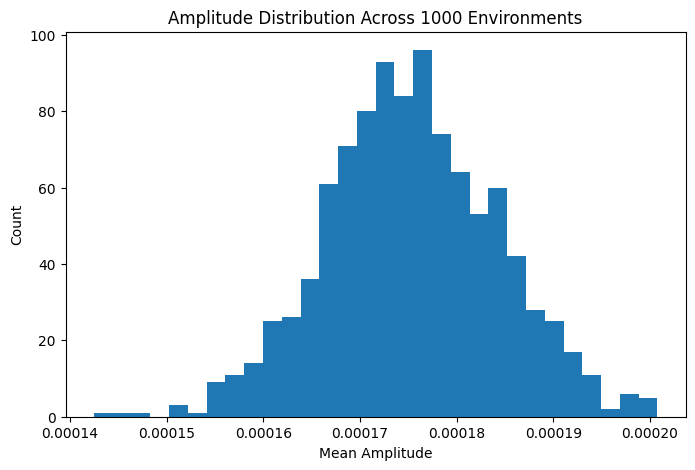

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(amps, bins=30)

plt.xlabel("Mean Amplitude")
plt.ylabel("Count")
plt.title("Amplitude Distribution Across 1000 Environments")

plt.show()

In [16]:
amps = np.array(amps)

print("Range :", np.max(amps)-np.min(amps))
print("Max/Min :", np.max(amps)/np.min(amps))

Range : 5.830253940075636e-05
Max/Min : 1.4092225943265373


### 객체별 분포 보기 

In [17]:
from collections import defaultdict
import numpy as np

obj_amp = defaultdict(list)

for env in results:
    amp = env["amp"]

    for obj in env["objects"]:
        obj_amp[obj["type"]].append(amp)

for obj_type in sorted(obj_amp):
    print(
        obj_type,
        np.mean(obj_amp[obj_type])
    )

bookshelf 0.00017271479431570083
chair 0.0001743368138755921
door 0.00017222820920429768
human 0.00017637315649175788
metal_panel 0.0001783302005241575
refrigerator 0.0001811499725728844
table 0.00017215642056021097
tv 0.0001782419024639933
wardrobe 0.00017045245202939197


1000개의 랜덤 환경에서 CSI amplitude 분포가 최대 6.5배 차이를 보였으며, 장애물 수가 증가할수록 평균 amplitude가 지속적으로 감소하였다. 이는 생성된 Environment Variation이 물리적으로 의미 있는 CSI perturbation을 유발함을 보여준다.

### 렌더링 ( 시각화 )

<class 'matplotlib.figure.Figure'>


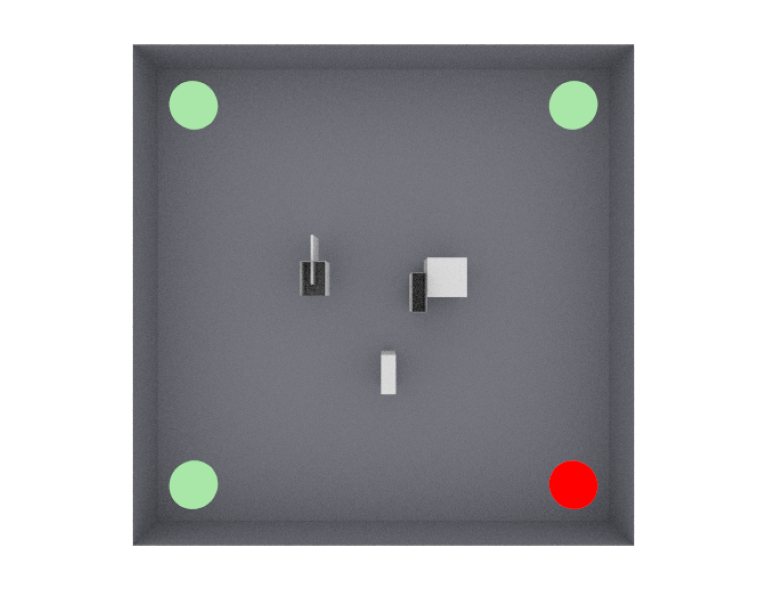

In [25]:
def render_scene(scene,
                 sim_scene,
                 camera,
                 filename):

    with scene.use_mi_scene(sim_scene):

        scene.render_to_file(
            camera=camera,
            filename=filename
        )


test_scene = load_base_scene()


# 보고 싶은 환경 번호
env_id = np.argmax([
    r["num_objects"]
    for r in results
])

scene, sim_scene = build_scene(
    load_base_scene(),
    results[env_id]["objects"]
)

from sionna.rt import Camera

cam = Camera(
    position=[0, 0, 20],
    look_at=[0, 0, 0]
)

with scene.use_mi_scene(sim_scene):

    img = scene.render(
        camera=cam,
        clip_at=2.0,
        clip_plane_orientation=(0,0,-1)
    )

print(type(img))

In [21]:
scene = load_base_scene()

with scene.use_mi_scene(scene.mi_scene):
    scene.preview(
    clip_at=1.5
)

In [20]:
obj = create_object(
    obj_type="chair",
    x=0,
    y=0,
    z=1,
    obj_id=0
)

print(obj)
print(type(obj))

<class 'sionna.rt.scene_object.SceneObject'>
